[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A8_procurement_spend.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's eighth appendix (see `README.md`), written like the module's core notebooks: same rhythm, same ✋/🧪/🧠 ladder. It runs on the core course stack (`numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`) with all data generated inline — 100 % offline.

---
# 📓 Notebook A8 (IA) — Procurement: Spend, Supplier Scorecards & Total Cost

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

Every notebook in this module so far has sat on the *selling* side of NB 25's B2B webshop — who to keep (NB 23), what to charge (A1), who gets credit (A3). This one walks through the door nobody visits: the **buying office**. The webshop resells what it purchases — 12 product categories, ~60 suppliers, roughly **€11 M a year across 14,000 purchase-order lines** — and it has a new head of procurement who asks the three questions every category manager gets asked in week one: *where does the money actually go* (spend transparency), *which suppliers are actually good* (scorecards — and "good" is subtler than "cheap" or "fast on average"), and *should we consolidate the long tail of suppliers* (a decision with switching costs and failure risk attached, not a sorting exercise).

Here is the methodological claim up front, because it is the opposite of what this module has trained you to expect: **procurement analytics is mostly not prediction.** There is no churn probability to estimate and no forecast to backtest. It is honest accounting plus a handful of distributions — and its two classic failures are *averaging away variance* (a supplier with the same mean lead time can cost you thousands in safety stock, §3) and *claiming savings on price while total cost rises* (§2 and §4). Both failures are planted in this notebook's data, and both get dissected.

> 🧠 **Mental model.** A procurement "saving" must survive three challenges before it is money. **Like-for-like:** same item, same lot size, same urgency — or you are measuring the basket, not the price. **Total cost:** defects, delivery variance, payment terms and admin ride on every invoice — or you are measuring the sticker, not the bill. **Risk-adjusted:** if the cheaper path concentrates your supply, you sold insurance and booked the premium as profit. A number that survives all three is a decision; everything else is a slide.

## 🎯 Learning objectives

By the end you can:

1. Turn a raw PO-line table into a **spend cube** and an **ABC/Pareto** view, and price **maverick spend** (off-contract buying) in €/yr against a like-for-like benchmark — without peeking at the generator.
2. Run a **price-variance analysis** that separates negotiable premium from *legitimate* dispersion (lot sizes, rush orders, input-cost drift) — and quantify how far the naive "everyone pays the minimum" savings claim overshoots the honest one.
3. Fit a **should-cost regression** and use its residuals — not raw prices — to find the lines that are genuinely overpriced.
4. Build a **supplier scorecard** whose weights are derived from euros at stake, compute **OTIF**, and price lead-time *variance* with NB 26's safety-stock formula — then explain why "rank by average lead time" promotes exactly the wrong supplier.
5. Fold defects, freight, terms and admin into **total cost of ownership**, and produce a **consolidation plan** ranked by payback — with the two brakes applied: switching costs and concentration risk (including the dual-source premium worth paying).
6. Say what this notebook deliberately did not solve — spend classification, contract compliance, supplier risk feeds — and where the scorecard should defer to the category manager (the honest section).

## ✅ Prerequisites

**NB 25** (the B2B webshop whose buying side this is), **NB 26** (safety stock, service levels — §3 reuses its formula and its σ logic), **NB 24** (expected-cost arithmetic; §5 runs on it), and **A3** (§5's insurance framing returns here, and we use the same 8 % cost of capital). **NB 10**'s confidence intervals resurface in Stretch A. All data is generated inline; everything runs offline.

In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

WACC = 0.08              # the webshop's cost of capital (same figure A3/A6 use)
HOLD_RATE = 0.22         # annual holding cost per EUR of inventory (NB 26)
ADMIN_PO = 14.0          # processing one PO line end-to-end (P2P benchmark, EUR)
ADMIN_SUPPLIER = 950.0   # keeping one supplier on the books for a year (EUR)
COQ = 1.2                # cost of quality per defective unit, as a multiple of its price
Z95 = 1.645              # z for a 95% cycle service level (NB 26)

def phi(x):              # standard normal CDF, stdlib only
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))

print(f"Cost of capital {WACC:.0%}/yr | holding {HOLD_RATE:.0%}/yr | EUR {ADMIN_PO:.0f} per PO line | "
      f"EUR {ADMIN_SUPPLIER:.0f} per supplier-year | z(95%) = {Z95}")

Cost of capital 8%/yr | holding 22%/yr | EUR 14 per PO line | EUR 950 per supplier-year | z(95%) = 1.645


## 1. The business: 14,000 PO lines, one spend cube

The ERP can export exactly one useful thing: the **purchase-order line**. One row = one item, ordered from one supplier by one department on one date — quantity, unit price, the framework-contract price it *should* have referenced, a flag for whether it did (`maverick = True` means the buyer went around the contract), promised vs. actual delivery, whether the delivery was complete, and how many units came in defective. Fourteen thousand of those rows, two years, and every question in this notebook is some `groupby` over them.

Two cells: first the master data (12 categories, 5 suppliers each — concentrated in tech categories, fragmented in commodities, which is how real supply markets look), then the lines themselves. As always in this module the generator **plants the ground truth** — a +9 % off-contract premium, lot-size price breaks, one supplier with a secret — so we can check our estimates against it later.

In [2]:
# ---- the buying office's master data: 12 categories, 60 suppliers ----
rng = np.random.default_rng(7)

CATS = {  # category: (line share, mean lot size, base unit price EUR, n items)
    "laptops & PCs":        (0.055,   9, 775.00, 4),
    "monitors":             (0.075,  16, 227.00, 4),
    "printers & shredders": (0.045,   7, 382.00, 4),
    "networking":           (0.055,  12, 179.00, 4),
    "toner & ink":          (0.135,  26,  80.00, 5),
    "storage & media":      (0.065,  26,  53.00, 4),
    "peripherals":          (0.095,  38,  25.80, 5),
    "cables & adapters":    (0.115,  55,   7.70, 6),
    "office furniture":     (0.040,   6, 254.00, 4),
    "paper & print":        (0.130, 115,   5.45, 4),
    "batteries & power":    (0.085,  44,  21.00, 4),
    "facility & cleaning":  (0.105,  60,  14.20, 5),
}
ITEM_MULT = [0.55, 0.80, 1.00, 1.35, 2.00, 2.60]      # item price ladder within a category
ITEM_W = [0.34, 0.26, 0.18, 0.12, 0.06, 0.04]         # item order-frequency weights

BUYERS = {  # department: (line share, negotiated-price factor, P(off-contract))
    "IT operations":    (0.22, 1.000, 0.05), "office services": (0.20, 1.005, 0.08),
    "logistics":        (0.12, 1.010, 0.10), "marketing":       (0.08, 1.020, 0.16),
    "sales ops":        (0.08, 1.015, 0.12), "facilities":      (0.10, 1.005, 0.07),
    "HQ admin":         (0.06, 1.000, 0.06), "regional offices": (0.14, 1.030, 0.32),
}

STEMS = ["Albrecht", "Bergmann", "Conradi", "Dallmann", "Ebert", "Falkenberg", "Grunewald", "Hartkopf",
         "Ihlenfeld", "Jansen", "Kessler", "Lindner", "Mertens", "Neuhaus", "Ostwald", "Paulsen",
         "Quast", "Rothermel", "Siebert", "Tessmer", "Ullrich", "Vogelsang", "Weidner", "Ziegler",
         "Ahrens", "Borchert", "Clausen", "Dörfler", "Eickhoff", "Fromm", "Gellert", "Hufnagel",
         "Isenberg", "Jochheim", "Kranz", "Lauterbach", "Michels", "Nolte", "Oberländer", "Petersen",
         "Quirin", "Reinecke", "Sattler", "Trautmann", "Unger", "Vollmer", "Wiedemann", "Zorn",
         "Amsel", "Brinkmann", "Cordes", "Dietrich", "Engelhardt", "Fiedler", "Grimm", "Heckmann",
         "Ilgner", "Jaspers", "Koopmann", "Lorenz"]
TRADE = {"laptops & PCs": "IT-Systemhaus", "monitors": "Displaytechnik",
         "printers & shredders": "Bürogeräte", "networking": "Netzwerktechnik",
         "toner & ink": "Druckerzubehör", "storage & media": "Datentechnik",
         "peripherals": "Computerzubehör", "cables & adapters": "Kabeltechnik",
         "office furniture": "Objekteinrichtung", "paper & print": "Papierhandel",
         "batteries & power": "Elektrohandel", "facility & cleaning": "Betriebsbedarf"}
SUFFIX = ["GmbH", "AG", "KG", "GmbH & Co. KG", "e.K."]
SHARES = {  # within-category volume shares, rank 1..5 — concentrated tech, fragmented commodities
    "laptops & PCs":        [0.62, 0.22, 0.09, 0.04, 0.03],
    "monitors":             [0.55, 0.28, 0.10, 0.04, 0.03],
    "printers & shredders": [0.45, 0.30, 0.15, 0.06, 0.04],
    "networking":           [0.58, 0.25, 0.10, 0.04, 0.03],
    "toner & ink":          [0.52, 0.28, 0.12, 0.05, 0.03],
    "storage & media":      [0.50, 0.27, 0.13, 0.06, 0.04],
    "peripherals":          [0.34, 0.27, 0.19, 0.12, 0.08],
    "cables & adapters":    [0.30, 0.26, 0.20, 0.14, 0.10],
    "office furniture":     [0.50, 0.28, 0.13, 0.06, 0.03],
    "paper & print":        [0.32, 0.26, 0.20, 0.13, 0.09],
    "batteries & power":    [0.38, 0.28, 0.16, 0.11, 0.07],
    "facility & cleaning":  [0.30, 0.25, 0.20, 0.15, 0.10],
}
TERMS_MENU = ["net 30", "net 45", "net 60", "2/10 net 30"]

rows, i = [], 0
for cat in CATS:
    for r, w in enumerate(SHARES[cat]):
        tail = r >= 3
        rows.append(dict(
            supplier=f"{STEMS[i]} {TRADE[cat]} {SUFFIX[i % 5]}", category=cat, cat_share=w,
            price_f=(rng.uniform(1.015, 1.055) if tail else float(np.clip(rng.normal(1.0, 0.02), 0.965, 1.05))),
            mu_lt=rng.uniform(4, 10), sig_lt=rng.uniform(0.6, 2.4),
            fill=rng.uniform(0.93, 0.995), defect=rng.uniform(0.003, 0.022),
            freight_pct=rng.uniform(0.015, 0.04), terms=str(rng.choice(TERMS_MENU, p=[.40, .25, .10, .25]))))
        i += 1
sup_master = pd.DataFrame(rows)

# hand-tuned corners of the story (every course generator plants its ground truth)
sup_master.loc[20, ["supplier", "price_f", "mu_lt", "sig_lt", "fill", "defect", "terms"]] = \
    ["Druckwerk Süd GmbH", 1.005, 7.1, 0.8, 0.99, 0.004, "2/10 net 30"]       # toner #1: boring, reliable
sup_master.loc[21, ["supplier", "price_f", "mu_lt", "sig_lt", "fill", "defect", "terms"]] = \
    ["Wexler Bürobedarf GmbH", 0.972, 6.8, 3.5, 0.93, 0.038, "net 14"]        # toner #2: cheap, erratic
sup_master.loc[22:24, "mu_lt"] = rng.uniform(7.6, 9.5, 3)                     # rest of toner: slower means
sup_master.loc[25, ["mu_lt", "sig_lt"]] = [6.0, 0.7]                          # storage #1: steady
sup_master.loc[27, ["mu_lt", "sig_lt"]] = [6.2, 2.9]                          # storage #3: jittery
sup_master.loc[41, ["supplier", "price_f"]] = ["Pfeiffer Objekteinrichtung KG", 1.062]   # furniture #2
sup_master.loc[44, ["supplier", "mu_lt", "sig_lt", "fill"]] = \
    ["Quandt Objektmöbel e.K.", 4.5, 0.5, 1.0]                                # furniture #5: tiny and perfect
sup_master["promised"] = np.clip(np.ceil(sup_master.mu_lt + sup_master.sig_lt), 5, 14).astype(int)
sup_master.loc[[20, 21], "promised"] = 9                                      # the twins quote the same
sup_master.loc[44, "promised"] = 7

print(f"{len(sup_master)} suppliers across {len(CATS)} categories; 5 per category, "
      f"concentrated tech categories, fragmented commodity ones")
print(sup_master.loc[[20, 21, 44], ["supplier", "category", "price_f", "mu_lt", "sig_lt", "defect", "terms"]]
      .to_string(index=False))

60 suppliers across 12 categories; 5 per category, concentrated tech categories, fragmented commodity ones
               supplier         category  price_f  mu_lt  sig_lt   defect       terms
     Druckwerk Süd GmbH      toner & ink 1.005000    7.1     0.8 0.004000 2/10 net 30
 Wexler Bürobedarf GmbH      toner & ink 0.972000    6.8     3.5 0.038000      net 14
Quandt Objektmöbel e.K. office furniture 1.036695    4.5     0.5 0.010248 2/10 net 30


In [3]:
# ---- two years of PO lines (2024-01 .. 2025-12), one row per order line ----
N = 14_000
cat_names = list(CATS)
cat_idx = rng.choice(len(cat_names), N, p=[CATS[c][0] for c in cat_names])
days = rng.integers(0, 730, N)
date = pd.Timestamp("2024-01-01") + pd.to_timedelta(days, "D")
year = date.year.to_numpy()
month_no = (year - 2024) * 12 + date.month.to_numpy() - 1                     # 0..23

STEEL = np.round(100 + 16 * np.sin(np.pi * np.arange(24) / 23) + rng.normal(0, 1.2, 24), 1)

qty = np.empty(N)
item = np.empty(N, dtype=object)
contract = np.empty(N)
qty_ref = np.empty(N)
for k, cat in enumerate(cat_names):
    m = cat_idx == k
    share, qmean, base, n_items = CATS[cat]
    lot_mean = np.where((year[m] == 2025) & (cat == "cables & adapters"), qmean * 0.5, qmean)
    qty[m] = np.maximum(1, np.round(rng.gamma(2.2, lot_mean / 2.2)))
    ids = rng.choice(n_items, m.sum(), p=np.array(ITEM_W[:n_items]) / sum(ITEM_W[:n_items]))
    item[m] = [f"{cat.split(' ')[0][:3].upper()}-{j + 1:02d}" for j in ids]
    c = base * np.array(ITEM_MULT)[ids]                                       # framework-contract price
    if cat == "office furniture":
        c = c * (0.62 + 0.38 * STEEL[month_no[m]] / 100)                      # steel is ~38% of cost
    if cat == "cables & adapters":
        c = c * np.where(year[m] == 2025, 0.985, 1.0)                         # 2025 renegotiation: -1.5%
    contract[m] = c
    qty_ref[m] = qmean

sup_rows = np.empty(N, dtype=int)
for k, cat in enumerate(cat_names):
    m = cat_idx == k
    sup_rows[m] = 5 * k + rng.choice(5, m.sum(), p=SHARES[cat])
S = sup_master.iloc[sup_rows].reset_index(drop=True)

b_names = list(BUYERS)
buyer = rng.choice(b_names, N, p=[BUYERS[b][0] for b in b_names])
buyer_f = np.array([BUYERS[b][1] for b in buyer])
maverick = rng.random(N) < np.array([BUYERS[b][2] for b in buyer])
rush = rng.random(N) < 0.07

lot_f = 1 + 0.18 * np.exp(-qty / qty_ref)                                     # small lots pay more
unit_price = (contract * lot_f * np.where(rush, 1.06, 1.0) * buyer_f
              * np.where(maverick, 1.09, 1.0) * S.price_f.to_numpy()
              * (1 + rng.normal(0, 0.012, N)))

lead = rng.normal(S.mu_lt, S.sig_lt)
wx = (S.supplier == "Wexler Bürobedarf GmbH").to_numpy()
mix = rng.random(N) < 0.18                                                     # Wexler: mostly fast ...
lead[wx] = np.where(mix[wx], rng.normal(13.6, 2.6, wx.sum()), rng.normal(5.3, 1.1, wx.sum()))
lead = np.maximum(1, lead)

po = pd.DataFrame({
    "date": date, "year": year, "category": np.array(cat_names)[cat_idx], "item": item,
    "supplier": S.supplier.to_numpy(), "buyer": buyer, "qty": qty.astype(int),
    "unit_price": unit_price.round(2), "contract_price": contract.round(2),
    "maverick": maverick, "rush": rush, "steel_idx": STEEL[month_no],
    "promised_days": S.promised.to_numpy(), "lead_time": lead.round(1),
    "in_full": rng.random(N) < S.fill.to_numpy(),
    "defect_units": rng.binomial(qty.astype(int), S.defect.to_numpy()),
})
po["on_time"] = po.lead_time <= po.promised_days
po["value"] = (po.qty * po.unit_price).round(2)
po["freight"] = np.maximum(14.0, S.freight_pct.to_numpy() * po.value).round(2)
po["lot_band"] = pd.cut(po.qty / qty_ref, [0, 0.5, 1.5, np.inf], labels=["small", "mid", "large"])

print(f"{len(po):,} PO lines, {po.date.min():%b %Y} – {po.date.max():%b %Y} | "
      f"spend EUR {po.value.sum() / 2 / 1e6:.2f}M per year | {po.supplier.nunique()} suppliers, "
      f"{po.item.nunique()} items, {po.buyer.nunique()} buying departments")
print(po[["date", "category", "item", "supplier", "buyer", "qty", "unit_price",
          "maverick", "lead_time", "in_full"]].head(4).to_string(index=False))

14,000 PO lines, Jan 2024 – Dec 2025 | spend EUR 10.88M per year | 60 suppliers, 53 items, 8 buying departments
      date            category   item                            supplier            buyer  qty  unit_price  maverick  lead_time  in_full
2024-11-16 facility & cleaning FAC-03           Jaspers Betriebsbedarf KG regional offices   49       16.10     False        5.1     True
2025-08-30         peripherals PER-02        Gellert Computerzubehör GmbH  office services   35       22.37     False        6.0     True
2024-11-28     storage & media STO-02 Eickhoff Datentechnik GmbH & Co. KG    IT operations   30       46.20     False       10.6     True
2024-01-20       paper & print PAP-03           Vollmer Papierhandel GmbH  office services  113        6.40      True        5.5     True


**€10.88 M a year.** Before any model: who gets it? The *spend cube* is procurement's first deliverable — spend by category, by supplier, by both — and the Pareto view of it decides everything downstream, because effort follows euros. The classic shape to expect (and we planted it, because every real spend cube has it): **A-suppliers** carrying ~70 % of spend, **B** the next ~20 %, and a long **C-class tail** of suppliers who each sell us almost nothing but cost the same €950 a year to keep on the books — master data, audits, invoices, the annual "please update your certificates" dance. That per-supplier overhead figure is a mid-range purchase-to-pay benchmark; real quotes run roughly €800–1,200 per supplier-year.

spend by category (EUR/yr):
category
laptops & PCs           2301
toner & ink             1907
monitors                1692
printers & shredders     754
networking               715
facility & cleaning      640
peripherals              595
storage & media          580
paper & print            508
batteries & power        477
office furniture         447
cables & adapters        259

ABC classes (A = first 70% of spend, B = next 20%, C = rest):
        n  spend_yr  share
value                     
A      17      7558   69.5
B      18      2173   20.0
C      25      1145   10.5

the long tail: 25 C-class suppliers carry 10.5% of spend — EUR 1,144,788/yr, averaging EUR 45,792 per supplier


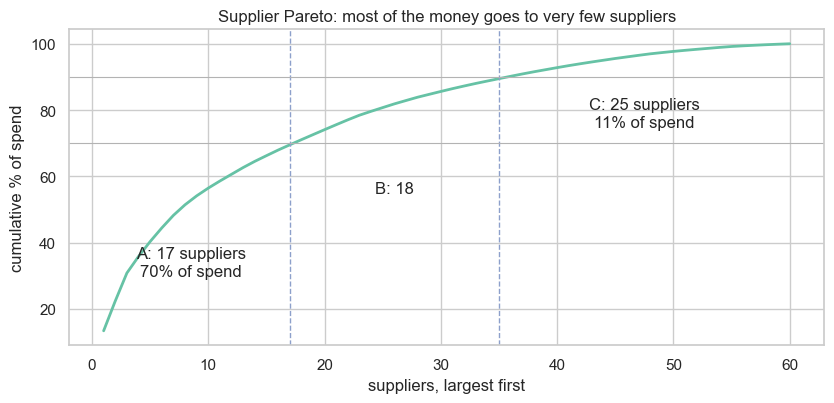

In [4]:
# ---- the spend cube and the Pareto ----
cat_spend = po.groupby("category").value.sum().sort_values(ascending=False) / 2
print("spend by category (EUR/yr):")
print((cat_spend / 1e3).round(0).astype(int).to_string())

sup_spend = po.groupby("supplier").value.sum().sort_values(ascending=False) / 2
cum = sup_spend.cumsum() / sup_spend.sum()
abc = pd.cut(cum, [0, 0.70, 0.90, 1.0], labels=["A", "B", "C"])
abc_tab = sup_spend.groupby(abc, observed=True).agg(n="size", spend_yr="sum")
abc_tab["share"] = abc_tab.spend_yr / sup_spend.sum()
print("\nABC classes (A = first 70% of spend, B = next 20%, C = rest):")
print(abc_tab.assign(spend_yr=lambda d: (d.spend_yr / 1e3).round(0).astype(int),
                     share=lambda d: (d.share * 100).round(1)).to_string())
c_mask = abc == "C"
print(f"\nthe long tail: {c_mask.sum()} C-class suppliers carry {abc_tab.loc['C', 'share']:.1%} of spend — "
      f"EUR {abc_tab.loc['C', 'spend_yr']:,.0f}/yr, averaging EUR {abc_tab.loc['C', 'spend_yr'] / c_mask.sum():,.0f} "
      f"per supplier")

# FIG 1 — the Pareto curve
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(np.arange(1, 61), cum.to_numpy() * 100, color="#66c2a5", lw=2)
n_a, n_b = (abc == "A").sum(), (abc == "B").sum()
ax.axvline(n_a, color="#8da0cb", ls="--", lw=1)
ax.axvline(n_a + n_b, color="#8da0cb", ls="--", lw=1)
ax.axhline(70, color="#b3b3b3", lw=0.8)
ax.axhline(90, color="#b3b3b3", lw=0.8)
ax.text(n_a / 2, 30, f"A: {n_a} suppliers\n70% of spend", ha="center")
ax.text(n_a + n_b / 2, 55, f"B: {n_b}", ha="center")
ax.text((n_a + n_b + 60) / 2, 75, f"C: {60 - n_a - n_b} suppliers\n{abc_tab.loc['C', 'share']:.0%} of spend", ha="center")
ax.set_xlabel("suppliers, largest first")
ax.set_ylabel("cumulative % of spend")
ax.set_title("Supplier Pareto: most of the money goes to very few suppliers")
plt.tight_layout()

Read the table the way the head of procurement will: **17 suppliers get 69.5 % of the money; 25 suppliers share the last 10.5 %**, averaging €45,792 each. The A-list is where negotiation hours pay for themselves; the C-tail is where *administration* eats the margin — €950 of annual overhead against €45,792 of average spend is 2.1 % before anyone has even looked at prices. Park that thought; it becomes §5's consolidation case.

First, though, the cheapest finding in all of procurement analytics — the one that needs no model at all. Some of these lines ignored the framework contract entirely. What did that cost? We price it **honestly**: each off-contract line is compared to the *median on-contract price for the same item in the same lot band* — a benchmark built from the data, not from the generator's secret.

In [5]:
# ---- maverick spend: buying off-contract, priced from the data (no god mode) ----
bench = po[~po.maverick].groupby(["item", "lot_band"], observed=True).unit_price.median()
b = pd.MultiIndex.from_frame(po[["item", "lot_band"]]).map(bench)
mav = po[po.maverick]
premium_yr = ((mav.unit_price - b[po.maverick.to_numpy()].to_numpy()) * mav.qty).sum() / 2
true_premium = (mav.value - mav.value / 1.09).sum() / 2      # generator's planted truth

print(f"off-contract lines : {po.maverick.mean():5.1%} of lines, {mav.value.sum() / po.value.sum():.1%} of spend")
print(f"estimated premium  : EUR {premium_yr:,.0f} per year vs the on-contract benchmark price")
print(f"planted truth      : EUR {true_premium:,.0f} per year (the +9% the generator charged)")
print()
by_buyer = (po.assign(mav_val=po.value.where(po.maverick, 0.0)).groupby("buyer")
            .agg(spend_yr=("value", lambda v: v.sum() / 2), mav_share=("maverick", "mean")))
print(by_buyer.assign(spend_yr=lambda d: (d.spend_yr / 1e3).round(0).astype(int),
                      mav_share=lambda d: (d.mav_share * 100).round(1))
      .sort_values("mav_share", ascending=False).to_string())

off-contract lines : 11.4% of lines, 11.9% of spend
estimated premium  : EUR 116,936 per year vs the on-contract benchmark price
planted truth      : EUR 106,931 per year (the +9% the generator charged)

                  spend_yr  mav_share
buyer                                
regional offices      1544       31.6
marketing              944       16.8
sales ops              915       12.0
logistics             1240        8.5
office services       2070        7.9
facilities            1116        6.6
HQ admin               697        6.4
IT operations         2350        4.8


**€116,936 a year** for the privilege of not using contracts that already exist — and our benchmark estimate lands within ~9 % of the planted truth (€106,931), slightly high because maverick lines also tend to come from the sloppier-negotiating departments, and the benchmark can't fully separate the two. The pattern is textbook: `regional offices` buys off-contract on **31.6 %** of its lines, the central `IT operations` on 4.8 %.

Say the quiet part out loud: a fully loaded procurement analyst costs €80–90 k a year. This single `groupby` — no model, no math beyond a median — **funds the entire analytics team**, and fixing it is a process change (route regional orders through the catalog), not a negotiation.

---

### ✋ Quick exercise (~2 min) — read the Pareto

Using `sup_spend`, `cum` and `abc` from the cube cell: **(a)** how many suppliers does it take to cover **80 %** of spend? **(b)** How much do the C-class suppliers sell us per year in total — and what does keeping all of them on the books (at `ADMIN_SUPPLIER` each) cost as a share of that spend?

In [6]:
# ✍️ Your turn 👇
# (a) suppliers until the cumulative share passes 0.80 — hint: (cum <= 0.80).sum() + 1
# (b) C-class spend: sup_spend[abc == "C"]; admin = count * ADMIN_SUPPLIER; divide


<details>
<summary>✅ <b>Solution</b></summary>

```python
cum80 = (cum <= 0.80).sum() + 1
c_class = sup_spend[abc == "C"]
print(f"suppliers needed for 80% of spend : {cum80} of 60")
print(f"C-class: {len(c_class)} suppliers, EUR {c_class.sum():,.0f}/yr of spend "
      f"({c_class.sum() / sup_spend.sum():.1%})")
print(f"C-class admin burden: {len(c_class)} x EUR {ADMIN_SUPPLIER:,.0f} = "
      f"EUR {len(c_class) * ADMIN_SUPPLIER:,.0f}/yr = {len(c_class) * ADMIN_SUPPLIER / c_class.sum():.1%} "
      f"of everything we buy from them")
```

**25 of 60** suppliers cover 80 % of spend — and the same count, 25, populates the C-class at the other end, carrying €1,144,788/yr between them. Their admin overhead is €23,750/yr, i.e. **2.1 % of everything we buy from them** — a hidden surcharge no invoice ever shows. §5 turns this into a plan.
</details>

## 2. The price-variance lens — same item, many prices

Second question a spend cube can answer without any modeling: **did we pay the same price for the same thing?** Group by item, look at the spread. If the answer were "yes" the max/min ratio would be ~1.0; watch what it actually is — and then watch what the *naive* savings claim built on it looks like. The naive claim is procurement's oldest self-deception: *"if every line had paid the minimum price we ever achieved for that item, we would have saved €X"*. Every consultant deck has this number. It is almost never money.

widest price dispersion (same item, 2 years):
                              n   p_min   p_med   p_max  max/min
category            item                                        
office furniture    OFF-01  213  141.95  163.25  204.41     1.44
toner & ink         TON-02  513   62.14   70.14   88.94     1.43
peripherals         PER-03  224   24.90   28.68   35.53     1.43
cables & adapters   CAB-02  435    5.97    6.87    8.44     1.41
facility & cleaning FAC-01  543    7.75    8.64   10.92     1.41
batteries & power   BAT-01  471   11.37   12.65   15.93     1.40

naive savings claim — 'if every line had paid the item's minimum price': EUR 968,594 per year


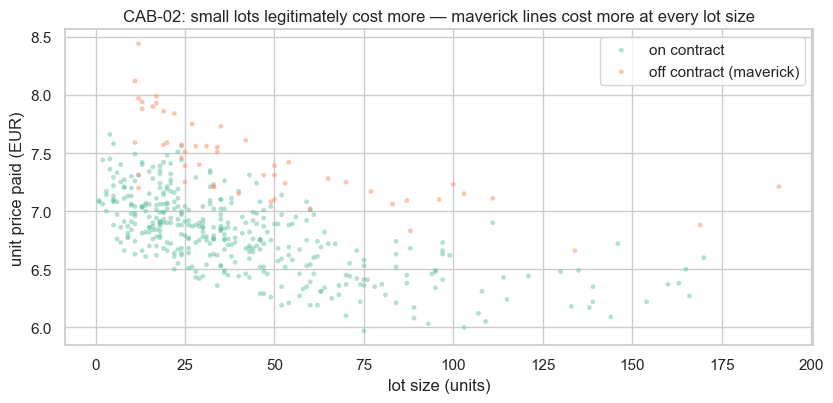

In [7]:
# ---- same item, many prices ----
disp = (po.groupby(["category", "item"]).unit_price
        .agg(n="size", p_min="min", p_med="median", p_max="max"))
disp["max/min"] = (disp.p_max / disp.p_min).round(2)
print("widest price dispersion (same item, 2 years):")
print(disp.sort_values("max/min", ascending=False).head(6).round(2).to_string())

item_min = po.groupby("item").unit_price.transform("min")
naive_yr = ((po.unit_price - item_min) * po.qty).sum() / 2
print(f"\nnaive savings claim — 'if every line had paid the item's minimum price': "
      f"EUR {naive_yr:,.0f} per year")

# FIG 2 — one cable item: price vs lot size, off-contract lines marked
one = po[po.item == "CAB-02"]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
for flag, color, label in [(False, "#66c2a5", "on contract"), (True, "#fc8d62", "off contract (maverick)")]:
    s = one[one.maverick == flag]
    ax.scatter(s.qty, s.unit_price, s=12, alpha=0.5, color=color, label=label, edgecolors="none")
ax.set_xlabel("lot size (units)")
ax.set_ylabel("unit price paid (EUR)")
ax.set_title("CAB-02: small lots legitimately cost more — maverick lines cost more at every lot size")
ax.legend()
plt.tight_layout()

A **1.4×** spread between the cheapest and dearest price *for the same item* — and a naive savings claim of **€968,594 a year**, a number large enough to end careers. Now look at the scatter before you believe it: unit price falls steeply with lot size (those are contractual **price breaks** — five monitors cost more per unit than fifty), rush orders carry a legitimate surcharge, and furniture prices drifted with a steel index all year. The 2-year minimum price was achieved by a *large, unhurried lot bought at the cheapest point of the input-cost wave*. "Everyone pays that" is not a negotiation strategy; it is a category manager's fantasy.

The honest version compares **like with like**: same item, same lot band, same rush status, same year — and only counts what was paid *above the median of that peer group*. And because our generator knows exactly which premia it planted (buyer sloppiness + the maverick 9 %), we can check the honest number against the truth:

In [8]:
# ---- the honest savings number: compare like with like ----
grp = ["item", "lot_band", "rush", "year"]
lfl_bench = po.groupby(grp, observed=True).unit_price.transform("median")
honest_yr = ((po.unit_price - lfl_bench).clip(lower=0) * po.qty).sum() / 2

# the generator knows the truly avoidable part: buyer sloppiness + the maverick premium
avoidable = (po.value - po.value / (np.array([BUYERS[b][1] for b in po.buyer])
                                    * np.where(po.maverick, 1.09, 1.0))).sum() / 2

print(f"naive claim  (pay the 2-year minimum, ignore lot size / rush / timing): EUR {naive_yr:>9,.0f} /yr")
print(f"honest claim (beat the like-for-like median: same item, lot band, rush, year): EUR {honest_yr:>9,.0f} /yr")
print(f"planted truth (buyer premia + maverick premium the generator actually charged): EUR {avoidable:>9,.0f} /yr")
print(f"\nthe gap — EUR {naive_yr - honest_yr:,.0f}/yr — is not savings; it is lot-size economics, "
      f"rush surcharges\nand input-cost drift dressed up as negotiation failure.")

naive claim  (pay the 2-year minimum, ignore lot size / rush / timing): EUR   968,594 /yr
honest claim (beat the like-for-like median: same item, lot band, rush, year): EUR   175,203 /yr
planted truth (buyer premia + maverick premium the generator actually charged): EUR   210,322 /yr

the gap — EUR 793,391/yr — is not savings; it is lot-size economics, rush surcharges
and input-cost drift dressed up as negotiation failure.


**€968,594 naive vs €175,203 honest** — and the honest number sits close to the planted truth of €210,322 (a bit under it: a median benchmark forgives half of each peer group by construction). The €793,391 gap **is the lesson of this section**: it is lot-size economics, rush surcharges and steel, dressed up as negotiation failure. Present the naive number and one of two things happens — finance annualizes it into your savings target, or the suppliers laugh you out of the room. Both are bad.

One refinement while we are here, because "compare within lot band" is a blunt instrument: fit the price. A **should-cost model** regresses log unit price on the things that *legitimately* move it — log lot size, the rush flag, the published steel index (for furniture, where steel is ~38 % of cost) and item dummies. Whatever the regression *cannot* explain is the residual — and a supplier whose lines sit systematically above should-cost is overpriced **after** every excuse has been priced in. That is a very different accusation from "your average price is high".

In [9]:
# ---- a should-cost model for office furniture: price ~ lot size + rush + steel ----
fur = po[po.category == "office furniture"].copy()
X = np.column_stack([np.log(fur.qty), fur.rush.astype(int), fur.steel_idx / 100,
                     pd.get_dummies(fur.item, drop_first=True).to_numpy()])
reg = LinearRegression().fit(X, np.log(fur.unit_price))
fur["resid_pct"] = (np.log(fur.unit_price) - reg.predict(X)) * 100

print(f"should-cost fit on {len(fur)} furniture lines  (R² = {reg.score(X, np.log(fur.unit_price)):.3f})")
print(f"  log(lot size): {reg.coef_[0] * 100:+.1f}%  per log-unit (bigger lots -> cheaper)")
print(f"  rush order   : {reg.coef_[1] * 100:+.1f}%")
print(f"  steel index  : {reg.coef_[2]:+.2f}  elasticity vs the published index")
print("\nmean residual by supplier (— = cheaper than should-cost, + = overpriced):")
print((fur.groupby("supplier").resid_pct.agg(["mean", "size"]).round(2)
       .sort_values("mean", ascending=False)).to_string())

should-cost fit on 591 furniture lines  (R² = 0.983)
  log(lot size): -5.0%  per log-unit (bigger lots -> cheaper)
  rush order   : +5.4%
  steel index  : +0.35  elasticity vs the published index

mean residual by supplier (— = cheaper than should-cost, + = overpriced):
                                           mean  size
supplier                                             
Pfeiffer Objekteinrichtung KG              3.67   150
Trautmann Objekteinrichtung GmbH & Co. KG  3.61    26
Sattler Objekteinrichtung KG               0.12    88
Quandt Objektmöbel e.K.                   -0.29    15
Quirin Objekteinrichtung GmbH             -2.09   312


The regression recovers the planted physics almost exactly — the rush surcharge comes back as **+5.4 %** (planted: +6 %), the steel elasticity as **+0.35** (planted: 0.38) — and the residual ranking does what raw price averages cannot: **Pfeiffer Objekteinrichtung KG sits +3.67 % above should-cost across 150 lines** with every legitimate driver already credited. That is the line item you take into a negotiation. (Trautmann's +3.61 % looks equally damning but rests on 26 lines — hold that thought until §3's small-`n` discussion and Stretch A.)

That's the price lens done honestly: dispersion → like-for-like → should-cost residuals. Now for the dimension the invoice never shows.

## 3. The supplier scorecard — where averages lie

"Which suppliers are good?" gets answered in industry with a **scorecard**: a handful of KPIs rolled into one number per supplier. The KPI everyone starts with is **OTIF — on-time, in-full**: the share of order lines that arrived by the promised date *and* complete. It is deliberately unforgiving (a delivery that is one day late *and* one carton short fails once, not twice) because downstream — a waiting customer, an idle packing station — partial success is failure.

Alongside OTIF we collect each supplier's mean lead time, its **standard deviation** (remember NB 26: σ is what safety stock is made of), its defect rate, and its average paid-vs-contract price ratio. And we impose a **volume floor** of 30 lines before anyone gets ranked — a league table that lets a 15-line supplier compete is a lottery, not a measurement (Stretch A makes that precise).

In [10]:
# ---- OTIF: on-time AND in-full, per supplier ----
MIN_LINES = 30
g = po.groupby("supplier")
sup = pd.DataFrame({
    "category": g.category.first(), "lines": g.size(), "spend_yr": g.value.sum() / 2,
    "otif": (po.on_time & po.in_full).groupby(po.supplier).mean(),
    "lt_mean": g.lead_time.mean(), "lt_sig": g.lead_time.std(),
    "defect": g.defect_units.sum() / g.qty.sum(),
    "price_ratio": (po.unit_price / po.contract_price).groupby(po.supplier).mean(),
})
active = sup[sup.lines >= MIN_LINES].copy()
show = active.assign(otif=lambda d: (d.otif * 100).round(1), lt_mean=lambda d: d.lt_mean.round(1),
                     lt_sig=lambda d: d.lt_sig.round(1), spend_yr=lambda d: (d.spend_yr / 1e3).round(0))
print(f"suppliers with >= {MIN_LINES} lines: {len(active)} of {len(sup)}")
print("\nbest OTIF:");  print(show.sort_values("otif", ascending=False).head(4)[["category", "lines", "otif", "lt_mean", "lt_sig"]].to_string())
print("\nworst OTIF:"); print(show.sort_values("otif").head(4)[["category", "lines", "otif", "lt_mean", "lt_sig"]].to_string())

toner = show[show.category == "toner & ink"].sort_values("lt_mean")
print("\nBASELINE — 'rank toner suppliers by average lead time' (fastest first):")
print(toner[["lines", "lt_mean", "lt_sig", "otif"]].to_string())

suppliers with >= 30 lines: 52 of 60

best OTIF:
                                category  lines  otif  lt_mean  lt_sig
supplier                                                              
Druckwerk Süd GmbH           toner & ink   1009  98.2      7.1     0.8
Quast Netzwerktechnik AG      networking    189  97.4      9.6     0.6
Wiedemann Papierhandel AG  paper & print    458  96.5      4.7     0.7
Zorn Papierhandel KG       paper & print    356  94.7      8.5     0.9

worst OTIF:
                                category  lines  otif  lt_mean  lt_sig
supplier                                                              
Wexler Bürobedarf GmbH       toner & ink    540  75.9      6.8     3.6
Hartkopf Displaytechnik KG      monitors    107  76.6      6.1     1.8
Ahrens Druckerzubehör e.K.   toner & ink     50  80.0      7.3     2.1
Hufnagel Computerzubehör AG  peripherals    360  81.1      8.7     2.3

BASELINE — 'rank toner suppliers by average lead time' (fastest first):
             

Druckwerk Süd tops the league at **98.2 %**; Wexler Bürobedarf props it up at **75.9 %** — one toner order in four arrives late, short, or both. So far, so obvious.

Now the trap this section exists for. The baseline every ops meeting actually uses is not OTIF — it is **"rank by average lead time"**, because the mean is the number the ERP shows. Look at that toner ranking again: it puts **Wexler first** (6.8 days beats Druckwerk's 7.1) — the supplier with the *worst OTIF in the entire company* wins the speed league. Both quote 9 days; both have honest-looking means. The difference is hiding in the column nobody sorts by, `lt_sig`: **0.8 vs 3.6 days**.

---

### ✋ Quick exercise (~2 min) — one supplier's OTIF, by hand

Filter `po` to `Wexler Bürobedarf GmbH` and compute three numbers: its **on-time** rate, its **in-full** rate, and its **OTIF** (both conditions at once). Roughly how many of its orders fail the joint test?

In [11]:
# ✍️ Your turn 👇
# lines = po[po.supplier == "Wexler Bürobedarf GmbH"]
# on-time: lines.on_time.mean() · in-full: lines.in_full.mean() · OTIF: (both together).mean()


<details>
<summary>✅ <b>Solution</b></summary>

```python
s = "Wexler Bürobedarf GmbH"
lines = po[po.supplier == s]
ot, inf_ = lines.on_time.mean(), lines.in_full.mean()
otif = (lines.on_time & lines.in_full).mean()
print(f"{s}: on-time {ot:.1%}, in-full {inf_:.1%}, OTIF (both at once) = {otif:.1%}")
print(f"roughly 1 toner order in {1 / (1 - otif):.0f} arrives late, short, or both")
```

On-time **82.8 %**, in-full **91.7 %**, OTIF **75.9 %** — roughly one order in four fails. Note that OTIF is the *joint* rate: here it happens to sit near the product of the two (the failure modes are nearly independent by construction), but in real data late deliveries are often also short — always compute the joint rate, never multiply.
</details>

### 🔮 Predict the output

Two toner suppliers, one `groupby`:

```python
TWINS = ["Druckwerk Süd GmbH", "Wexler Bürobedarf GmbH"]
print(po[po.supplier.isin(TWINS)].groupby("supplier").lead_time.agg(["count", "mean", "std"]).round(2))
```

Both promise 9 days. Before you run it: which of the two does the "rank by average lead time" baseline prefer — and by how much? And what do you expect in the `std` column, given what OTIF just told you?

                        count  mean   std
supplier                                 
Druckwerk Süd GmbH       1009  7.10  0.81
Wexler Bürobedarf GmbH    540  6.81  3.58


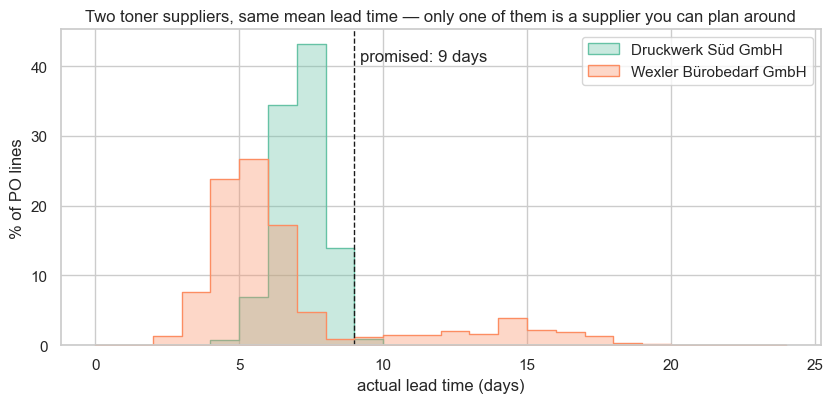

In [12]:
TWINS = ["Druckwerk Süd GmbH", "Wexler Bürobedarf GmbH"]
tw = po[po.supplier.isin(TWINS)]
print(tw.groupby("supplier").lead_time.agg(["count", "mean", "std"]).round(2).to_string())

# FIG 3 — same mean, different animal
fig, ax = plt.subplots(figsize=(8.5, 4.2))
for s, color in zip(TWINS, ["#66c2a5", "#fc8d62"]):
    sns.histplot(tw.loc[tw.supplier == s, "lead_time"], bins=np.arange(0, 25, 1),
                 stat="percent", element="step", alpha=0.35, color=color, label=s, ax=ax)
ax.axvline(9, color="k", ls="--", lw=1)
ax.text(9.2, ax.get_ylim()[1] * 0.9, "promised: 9 days")
ax.set_xlabel("actual lead time (days)")
ax.set_ylabel("% of PO lines")
ax.set_title("Two toner suppliers, same mean lead time — only one of them is a supplier you can plan around")
ax.legend()
plt.tight_layout()

The means are **7.10 vs 6.81 days** — statistically indistinguishable twins; the mean-lead-time baseline actually *prefers Wexler*. The histogram shows why that preference is a €-losing mistake: Druckwerk is a metronome (σ = 0.81), while Wexler is a **mixture** — about four orders in five arrive fast, and the rest take around two weeks. Averaging a mixture gives you a number that describes *neither* mode. You've met this failure before: NB 26 warned that σ, not the mean, sizes the buffer; A2 warned that "not significant on average" can hide structure. This is the procurement edition.

And NB 26 gave us the exact tool to price it. Safety stock against demand-during-lead-time is

$$ss = z \cdot \sqrt{\;\overline{LT}\,\sigma_d^2 \;+\; \bar d^{\,2}\,\sigma_{LT}^2\;}$$

— the second term under the root is **lead-time variance times demand squared**. A supplier's σ_LT walks straight into your warehouse as euros:

In [13]:
# ---- NB 26's safety-stock formula prices the difference ----
# demand during lead time: ss = z * sqrt(LT * sigma_d^2 + d_bar^2 * sigma_LT^2)
ton1 = po[po.item == "TON-01"]
d_bar = ton1.qty.sum() / 730                     # webshop's daily outflow of TON-01, from the PO volume
sigma_d = 0.4 * d_bar                            # NB 26's demand side; taken as given here
cost_unit = ton1.contract_price.median()

print(f"TON-01: d_bar = {d_bar:.1f} units/day, sigma_d = {sigma_d:.1f}, unit cost EUR {cost_unit:.2f}\n")
ss = {}
for s in TWINS:
    lt = po.loc[po.supplier == s, "lead_time"]
    ss[s] = Z95 * math.sqrt(lt.mean() * sigma_d**2 + d_bar**2 * lt.std()**2)
    cap = ss[s] * cost_unit
    print(f"{s:26s}: sigma_LT {lt.std():4.1f} d -> safety stock {ss[s]:5.0f} units "
          f"= EUR {cap:6,.0f} tied up, EUR {cap * HOLD_RATE:5,.0f}/yr holding")

d_units = ss[TWINS[1]] - ss[TWINS[0]]
print(f"\nvariance premium on this ONE item: {d_units:.0f} extra units, "
      f"EUR {d_units * cost_unit * HOLD_RATE:,.0f}/yr of holding cost")

# scale to Wexler's whole toner volume (safety stock scales with EUR flow)
wx_val = po[(po.supplier == TWINS[1])].value.sum() / 2 / 365   # EUR/day flowing through Wexler
dk_sig = po.loc[po.supplier == TWINS[0], "lead_time"].std()
wx_sig = po.loc[po.supplier == TWINS[1], "lead_time"].std()
extra_cap = Z95 * wx_val * (wx_sig - dk_sig)
print(f"across Wexler's full toner flow: ~EUR {extra_cap:,.0f} extra stock, "
      f"EUR {extra_cap * HOLD_RATE:,.0f}/yr of holding")

# and if you DON'T carry it: the service level you actually get with Druckwerk-sized stock
lt_w = po.loc[po.supplier == TWINS[1], "lead_time"]
z_eff = ss[TWINS[0]] / math.sqrt(lt_w.mean() * sigma_d**2 + d_bar**2 * lt_w.std()**2)
print(f"keep Druckwerk-sized stock but buy from Wexler -> effective service level "
      f"{phi(z_eff):.0%} instead of 95%")

# for scale: what is Wexler's celebrated price advantage actually worth?
wx_spend = po[po.supplier == TWINS[1]].value.sum() / 2
r_dk, r_wx = active.loc[TWINS[0], "price_ratio"], active.loc[TWINS[1], "price_ratio"]
print(f"for scale: Wexler moves EUR {wx_spend:,.0f}/yr of toner; its price advantage over Druckwerk "
      f"is ~EUR {(r_dk - r_wx) / r_wx * wx_spend:,.0f}/yr — §4 tests whether it survives the small print")

TON-01: d_bar = 22.9 units/day, sigma_d = 9.1, unit cost EUR 44.00

Druckwerk Süd GmbH        : sigma_LT  0.8 d -> safety stock    50 units = EUR  2,215 tied up, EUR   487/yr holding
Wexler Bürobedarf GmbH    : sigma_LT  3.6 d -> safety stock   140 units = EUR  6,168 tied up, EUR 1,357/yr holding

variance premium on this ONE item: 90 extra units, EUR 869/yr of holding cost
across Wexler's full toner flow: ~EUR 6,773 extra stock, EUR 1,490/yr of holding
keep Druckwerk-sized stock but buy from Wexler -> effective service level 72% instead of 95%
for scale: Wexler moves EUR 543,077/yr of toner; its price advantage over Druckwerk is ~EUR 21,002/yr — §4 tests whether it survives the small print


There is the invisible invoice, itemized. To hold the same 95 % service level on one toner SKU, Wexler forces **140 units of safety stock where Druckwerk needs 50** — €869/yr of extra holding on that item, roughly **€1,490/yr across Wexler's whole toner flow**. Refuse to carry it and the bill arrives anyway, as stockouts: Druckwerk-sized stock fed by Wexler's lead times delivers a **72 % service level, not 95 %** — on NB 26's arithmetic, that is the difference between a working reorder policy and a weekly firefight.

Is €1,490 a lot? Against the scale line — Wexler moves **€543,077/yr** of toner with a **~€21,002/yr** price advantage over Druckwerk — no: *variance alone* doesn't flip the decision. That is exactly why it survives in real supplier bases: each hidden cost is individually forgivable. §4 adds them all up.

---

### ✋ Quick exercise (~2 min) — price a σ gap yourself

Two *storage & media* suppliers, **Borchert Datentechnik GmbH** and **Dörfler Datentechnik KG**, have similar mean lead times but different jitter. Item `STO-01` flows at about **15 units/day** (take σ_d = 5), and its unit cost is its median `contract_price` in `po`. Using `Z95`, `HOLD_RATE` and each supplier's *empirical* lead-time mean and σ from `po`: what does Dörfler's jitter cost per year on this one item, relative to Borchert?

In [14]:
# ✍️ Your turn 👇
d_bar_s, sigma_d_s = 15.0, 5.0
# cost_s = po.loc[po.item == "STO-01", "contract_price"].median()
# for each supplier: lt = po.loc[po.supplier == s, "lead_time"]
#   ss = Z95 * math.sqrt(lt.mean() * sigma_d_s**2 + d_bar_s**2 * lt.std()**2)
#   holding EUR/yr = ss * cost_s * HOLD_RATE


<details>
<summary>✅ <b>Solution</b></summary>

```python
pair = ["Borchert Datentechnik GmbH", "Dörfler Datentechnik KG"]   # storage & media, ranks 1 and 3
d_bar_s, sigma_d_s = 15.0, 5.0
cost_s = po.loc[po.item == "STO-01", "contract_price"].median()
hold = {}
for s in pair:
    lt = po.loc[po.supplier == s, "lead_time"]
    ss_u = Z95 * math.sqrt(lt.mean() * sigma_d_s**2 + d_bar_s**2 * lt.std()**2)
    hold[s] = ss_u * cost_s * HOLD_RATE
    print(f"{s:32s} sigma_LT {lt.std():4.1f} d -> ss {ss_u:5.0f} units -> EUR {hold[s]:5,.0f}/yr holding")
print(f"delta = EUR {abs(hold[pair[1]] - hold[pair[0]]):,.0f}/yr — the invoice never shows it")
```

σ_LT of 0.7 vs 2.7 days → **€174 vs €450 a year** of holding on a single mid-priced item — a €276 gap that appears on no invoice and in no price negotiation. Multiply across a catalog and the 'fast on average' supplier quietly becomes the expensive one.
</details>

With OTIF, σ_LT, defects, price ratio and payment terms in hand, we can finally build the scorecard — and step around its classic design failure. The committee version assigns **equal weights** (20/20/20/20/20, the procurement cousin of 25/25/25/25) because equality feels objective. It isn't; it is an *implicit* claim that a percentage point of OTIF is worth exactly as much as a percentage point of defect rate, which nobody has checked. The alternative: **derive the weights from euros at stake** — for each dimension, how much money is actually in play across the portfolio per year? Price gets the honest-savings pool from §2; quality gets the cost-of-quality pool; terms the financing pool; OTIF an expediting cost per failed line; σ_LT the safety-stock capital we just learned to price.

In [15]:
# ---- the weighted scorecard: arbitrary weights first, then euro-derived ones ----
TERMS_DAYS = {"net 14": 14, "net 30": 30, "net 45": 45, "net 60": 60, "2/10 net 30": 10}
DISC = {"2/10 net 30": 0.02}
tv = sup_master.set_index("supplier").loc[active.index]
active["terms_pct"] = (np.array([DISC.get(t, 0.0) for t in tv.terms])
                       - WACC * (30 - np.array([TERMS_DAYS[t] for t in tv.terms])) / 365) * 100

def norm(s, higher_is_better):
    r = (s - s.min()) / (s.max() - s.min())
    return 100 * (r if higher_is_better else 1 - r)

dims = pd.DataFrame({"price": norm(active.price_ratio, False), "otif": norm(active.otif, True),
                     "lt_var": norm(active.lt_sig, False), "quality": norm(active.defect, False),
                     "terms": norm(active.terms_pct, True)}, index=active.index)

# euro pools: what is actually at stake per dimension, portfolio-wide, EUR/yr
daily_val = active.spend_yr / 365
best_sig = active.groupby(active.category).lt_sig.transform("min")
pools = pd.Series({
    "price":   honest_yr,
    "otif":    (~(po.on_time & po.in_full)).sum() / 2 * 28.0,               # chase/expedite a failed line
    "lt_var":  (Z95 * daily_val * (active.lt_sig - best_sig) * HOLD_RATE).clip(lower=0).sum(),
    "quality": (po.defect_units * po.contract_price * COQ).sum() / 2,
    "terms":   (active.terms_pct.abs() / 100 * active.spend_yr).sum(),
})
w = pools / pools.sum()
print("euro at stake per dimension (EUR/yr) -> weight:")
for d_ in pools.index:
    print(f"  {d_:8s} EUR {pools[d_]:>9,.0f}  ->  {w[d_]:.0%}")

active["score_eq"] = dims.mean(axis=1)                    # the committee version: 20/20/20/20/20
active["score_eur"] = dims.mul(w).sum(axis=1)
tn = active[active.category == "toner & ink"].copy()
tn["rank_eq"] = tn.score_eq.rank(ascending=False).astype(int)
tn["rank_eur"] = tn.score_eur.rank(ascending=False).astype(int)
print("\ntoner & ink, both scorecards (higher = better):")
print(tn[["score_eq", "rank_eq", "score_eur", "rank_eur", "otif", "lt_sig", "defect"]]
      .round(2).sort_values("rank_eur").to_string())
moved = (active.score_eq.rank(ascending=False) - active.score_eur.rank(ascending=False)).abs()
print(f"\nacross all {len(active)} scored suppliers, {int((moved >= 5).sum())} move 5+ ranks "
      f"when weights switch from equal to euro-derived")

euro at stake per dimension (EUR/yr) -> weight:
  price    EUR   175,203  ->  41%
  otif     EUR    23,310  ->  5%
  lt_var   EUR     6,893  ->  2%
  quality  EUR   144,117  ->  34%
  terms    EUR    75,631  ->  18%

toner & ink, both scorecards (higher = better):
                                      score_eq  rank_eq  score_eur  rank_eur  otif  lt_sig  defect
supplier                                                                                          
Weidner Druckerzubehör KG                82.21        2      84.86         1  0.91    1.31    0.00
Druckwerk Süd GmbH                       89.66        1      81.55         2  0.98    0.81    0.00
Ahrens Druckerzubehör e.K.               43.54        4      48.18         3  0.80    2.07    0.01
Wexler Bürobedarf GmbH                   19.84        5      40.89         4  0.76    3.58    0.03
Ziegler Druckerzubehör GmbH & Co. KG     44.68        3      38.64         5  0.87    1.62    0.01

across all 52 scored suppliers, 25 move 5

The euro pools embarrass the committee twice. First, the weights nobody would have voted for: **price 41 %, quality 34 %** — quality is nearly *as heavy as price* in this supplier base, while lead-time variance, the star of the last three cells, is worth only 2 % portfolio-wide (it is huge for the twins, negligible for most). Second, the reordering: **25 of 52 suppliers move five or more ranks** when the weights switch, and in toner the equal-weights winner Druckwerk is overtaken by Weidner — Druckwerk's OTIF halo (a dimension worth 5 % in euros) was propping up its equal-weights crown.

So the section's two named baselines both fall: *"rank by average lead time"* promoted the company's worst supplier, and the *equal-weights scorecard* shuffled half the league. A scorecard is a claim about exchange rates between KPIs — **argue the weights in euros or don't publish it**.

## 4. Defects, discounts and terms — small print in euros

Three cost lines that live in the contract's small print, each with a one-line valuation:

- **Defects.** A defective unit does not cost what the unit cost; it costs return freight, a replacement shipment, handling, and an annoyed customer. The standard move is a **cost-of-quality multiplier** — we use `COQ = 1.2×` unit price per defective unit, mid-range for distribution businesses.
- **Early-payment discounts.** `2/10 net 30` means: 2 % off if you pay within 10 days, full amount due in 30. Paying early costs you 20 days of financing at your WACC and earns 2 % — the NPV fits in one line.
- **Payment terms.** Every day past 30 that a supplier lets you keep the cash is worth `WACC/365` of the invoice. (That is the *value* of terms; the cash-flow mechanics — DSO, DPO, the financing gap — are A6's whole story.)

In [16]:
# ---- small print, priced: defects, discounts, terms ----
dq = (po.groupby("supplier").apply(lambda d_: (d_.defect_units * d_.contract_price * COQ).sum() / 2,
                                   include_groups=False).sort_values(ascending=False))
print("cost of quality, worst suppliers (EUR/yr = defective units x price x COQ):")
print(dq.head(4).round(0).astype(int).to_string())

# 2/10 net 30, in one line of NPV: pay 98 now-ish or 100 in 20 more days
disc_gain = 0.02 - WACC * 20 / 365
apr = (1 / 0.98) ** (365 / 20) - 1
print(f"\n2/10 net 30: taking the discount nets {disc_gain:.2%} of invoice value at WACC {WACC:.0%}")
print(f"skipping it = borrowing at {apr:.0%} APR — take the discount at any WACC below that")
print("(the cash-flow side of terms — DSO/DPO, the financing gap — is A6's whole story)")

terms_val = active.terms_pct / 100 * active.spend_yr
print(f"\npayment-terms value across scored suppliers: EUR {terms_val.sum():,.0f}/yr "
      f"(best single supplier: {terms_val.idxmax()}, EUR {terms_val.max():,.0f}/yr)")

cost of quality, worst suppliers (EUR/yr = defective units x price x COQ):
supplier
Wexler Bürobedarf GmbH         21372
Albrecht IT-Systemhaus GmbH    17926
Borchert Datentechnik GmbH      6916
Conradi IT-Systemhaus KG        6440

2/10 net 30: taking the discount nets 1.56% of invoice value at WACC 8%
skipping it = borrowing at 45% APR — take the discount at any WACC below that
(the cash-flow side of terms — DSO/DPO, the financing gap — is A6's whole story)

payment-terms value across scored suppliers: EUR 71,822/yr (best single supplier: Druckwerk Süd GmbH, EUR 15,268/yr)


Wexler again — **€21,372 a year of quality cost**, the single largest cost-of-quality line in the company, and almost exactly the size of the €21 k price advantage §3 measured: **the defects alone eat the entire discount** before freight, variance or terms say a word. And note the discount arithmetic: skipping a 2/10 net 30 discount is equivalent to **borrowing at 45 % APR**. Any supplier offering it is either testing whether your AP department is awake, or genuinely starved for cash — both are useful information. (File that thought: Wexler demands `net 14`. Suppliers who need your money *fast* are telling you something about §5's failure probabilities.)

---

### ✋ Quick exercise (~2 min) — the 2/10 net 30 NPV

A supplier offers **2/10 net 30** on a **€48,000** invoice; the webshop funds itself at `WACC` = 8 %. In euros: what does taking the discount net you on this invoice, after the cost of paying 20 days early? And what implied annual rate do you pay by *skipping* it?

In [17]:
# ✍️ Your turn 👇
inv = 48_000
# discount captured: inv * 0.02
# funding 20 extra days: inv * 0.98 * WACC * 20 / 365
# skip-APR: (1 / 0.98) ** (365 / 20) - 1


<details>
<summary>✅ <b>Solution</b></summary>

```python
inv = 48_000
gain = inv * 0.02 - inv * 0.98 * WACC * 20 / 365
print(f"discount captured : EUR {inv * 0.02:,.0f}")
print(f"funding 20 days   : EUR {inv * 0.98 * WACC * 20 / 365:,.2f}")
print(f"net gain          : EUR {gain:,.2f} on one invoice "
      f"({gain / inv:.2%} of its value)")
print(f"skip-the-discount APR: {(1 / 0.98) ** (365 / 20) - 1:.0%} — no treasurer funds at that rate")
```

€960 captured minus €206.20 of funding = **€753.80 net gain** on a single invoice — 1.57 % of its value, earned by moving a payment date. The skip-APR of 45 % is the punchline to remember: *no* plausible cost of capital makes skipping rational; if your company skips these discounts, that is a process bug wearing a treasury costume.
</details>

Now the assembly. **Total cost of ownership** puts every lens from §2–§4 on one invoice-shaped table: for each toner supplier, per **€100 of catalogue (contract-price) spend**, what do we actually pay once price, freight, quality, variance-driven inventory, terms and PO admin are counted? This is the table where the module's baseline *"rank suppliers by average price"* goes to die:

EUR per 100 of catalogue spend (lower = cheaper all-in):
                                       price  freight  quality  inventory  terms  admin     TCO  price share
supplier                                                                                                    
Weidner Druckerzubehör KG             107.52     2.24     0.42       0.13  -1.56   0.76  109.50         98.2
Druckwerk Süd GmbH                    108.90     4.16     0.55       0.08  -1.56   0.79  112.91         96.4
Wexler Bürobedarf GmbH                104.88     3.36     4.13       0.35   0.35   0.73  113.80         92.2
Ahrens Druckerzubehör e.K.            112.75     1.90     1.09       0.20  -0.33   0.64  116.25         97.0
Ziegler Druckerzubehör GmbH & Co. KG  112.42     3.56     1.72       0.16  -0.00   0.74  118.59         94.8

cheapest by invoice price: Wexler Bürobedarf GmbH  |  cheapest by TCO: Weidner Druckerzubehör KG


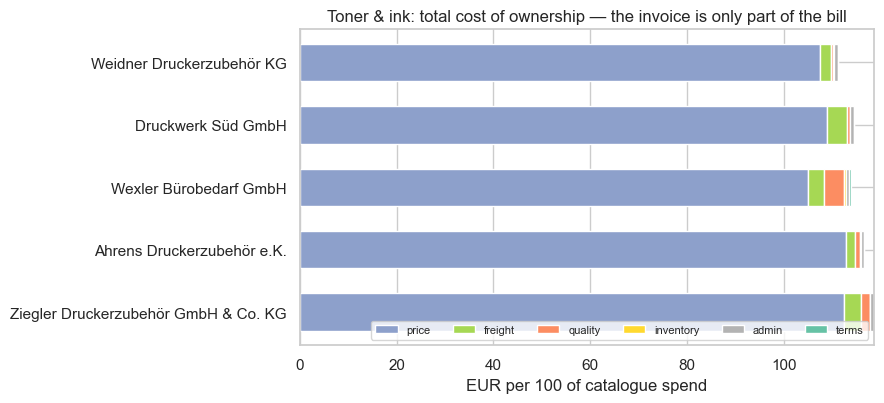

In [18]:
# ---- total cost of ownership, per EUR 100 of catalogue spend: toner & ink ----
rows = []
for s, d_ in po[po.category == "toner & ink"].groupby("supplier"):
    catalogue = (d_.contract_price * d_.qty).sum()
    lt = d_.lead_time
    daily = d_.value.sum() / 2 / 365
    inv_eur = Z95 * daily * lt.std() * HOLD_RATE                       # holding bought by THEIR variance
    tp = active.loc[s, "terms_pct"] if s in active.index else 0.0
    rows.append({
        "supplier": s,
        "price": 100 * d_.value.sum() / catalogue,
        "freight": 100 * d_.freight.sum() / catalogue,
        "quality": 100 * (d_.defect_units * d_.contract_price * COQ).sum() / catalogue,
        "inventory": 100 * inv_eur / (d_.value.sum() / 2),
        "terms": -100 * tp / 100,
        "admin": 100 * (len(d_) * ADMIN_PO) / catalogue,
    })
tco = pd.DataFrame(rows).set_index("supplier")
tco["TCO"] = tco.sum(axis=1)
tco["price share"] = (tco.price / tco.TCO * 100).round(1)
tco = tco.sort_values("TCO")
print("EUR per 100 of catalogue spend (lower = cheaper all-in):")
print(tco.round(2).to_string())
cheap_p, cheap_t = tco.price.idxmin(), tco.TCO.idxmin()
print(f"\ncheapest by invoice price: {cheap_p}  |  cheapest by TCO: {cheap_t}")

# FIG 4 — the same table as a picture
fig, ax = plt.subplots(figsize=(9, 4.2))
comps = ["price", "freight", "quality", "inventory", "admin", "terms"]
colors = ["#8da0cb", "#a6d854", "#fc8d62", "#ffd92f", "#b3b3b3", "#66c2a5"]
left = np.zeros(len(tco))
for c, col in zip(comps, colors):
    v = tco[c].clip(lower=0)
    ax.barh(tco.index, v, left=left, color=col, label=c, height=0.6)
    left += v.to_numpy()
ax.set_xlabel("EUR per 100 of catalogue spend")
ax.set_title("Toner & ink: total cost of ownership — the invoice is only part of the bill")
ax.legend(ncol=6, fontsize=8, loc="lower right")
ax.invert_yaxis()
plt.tight_layout()

**The cheapest supplier is not the cheapest supplier.** Wexler wins the invoice-price column at **€104.88** per €100 of catalogue — and loses the category at **€113.80 all-in**, beaten by Weidner (€109.50) *and* by Druckwerk (€112.91). The €4.13 quality line does most of the damage; freight, variance and its cash-hungry `net 14` terms finish the job. Meanwhile the two clean suppliers get *paid* for their terms (the −€1.56 credit is the 2/10 discount).

Read the `price share` column as the section's summary: for a well-run supplier the invoice is **~98 %** of the truth, and for a badly run one **~92 %** — the sticker never lies by much, but the ranking it produces is wrong exactly where it matters. TCO is not exotic accounting; it is six `groupby` columns, and it just reversed a sourcing decision on ~€534 k of annual spend.

## 5. The consolidation decision — the tail and the risk

Back to §1's parking lot: 25 C-class suppliers, €1.14 M of spend, €950 of annual overhead each. The consolidation pitch writes itself — *fold each tail supplier into its category's #1, pocket the admin, ride the bigger supplier's price level*. Before anyone signs it, two brakes.

**Brake 1 — switching costs.** Moving spend is not free: requalification, master-data surgery, first-article checks, sometimes tooling. We book €1,500 + 2 % of the moved annual spend per switch (plus €2,500 tooling for furniture) as one-off cost, and judge every candidate by **payback in months**, not by raw savings.

In [19]:
# ---- the long tail, and what it costs to keep ----
c_sup = sup.loc[sup_spend[abc == "C"].index].copy()
c_sup["admin_pct"] = ADMIN_SUPPLIER / c_sup.spend_yr
print(f"C-class: {len(c_sup)} suppliers, EUR {c_sup.spend_yr.sum():,.0f}/yr of spend, "
      f"EUR {len(c_sup) * ADMIN_SUPPLIER:,.0f}/yr of supplier admin")
print("\nsmallest ten (admin as % of what we buy from them):")
print((c_sup.sort_values("spend_yr")[["category", "lines", "spend_yr", "admin_pct"]]
       .assign(spend_yr=lambda d_: d_.spend_yr.round(0).astype(int),
               admin_pct=lambda d_: (d_.admin_pct * 100).round(1)).head(10)).to_string())

# raw candidates: fold each C supplier into its category's #1, at the #1's price level
top_by_cat = sup.loc[active.index].reset_index().sort_values("spend_yr", ascending=False) \
                .groupby("category").first()
cand = c_sup.copy()
cand["target"] = top_by_cat.loc[cand.category, "supplier"].to_numpy()
cand["price_gain"] = (cand.price_ratio - top_by_cat.loc[cand.category, "price_ratio"].to_numpy()) \
                     * cand.spend_yr
cand["saving_yr"] = ADMIN_SUPPLIER + cand.price_gain
cand["one_off"] = 1_500 + 0.02 * cand.spend_yr + np.where(cand.category == "office furniture", 2_500, 0)
cand["payback_m"] = cand.one_off / cand.saving_yr * 12
print(f"\nraw consolidation upside (before the two brakes): EUR {cand.saving_yr.sum():,.0f}/yr "
      f"across {len(cand)} tail suppliers")

C-class: 25 suppliers, EUR 1,144,788/yr of spend, EUR 23,750/yr of supplier admin

smallest ten (admin as % of what we buy from them):
                                                       category  lines  spend_yr  admin_pct
supplier                                                                                   
Quandt Objektmöbel e.K.                        office furniture     15     14449        6.6
Siebert Netzwerktechnik GmbH & Co. KG                networking     18     15894        6.0
Trautmann Objekteinrichtung GmbH & Co. KG      office furniture     26     18299        5.2
Fromm Datentechnik e.K.                         storage & media     26     18906        5.0
Tessmer Netzwerktechnik e.K.                         networking     27     22106        4.3
Eickhoff Datentechnik GmbH & Co. KG             storage & media     52     28546        3.3
Ostwald Bürogeräte e.K.                    printers & shredders     24     31825        3.0
Petersen Kabeltechnik e.K.           

**€60,460 a year of raw upside** — mostly admin relief plus the tail's spot-buy price premium. But notice what the naive plan would also do: in categories like laptops and monitors, the "fold everything into #1" logic finishes with the #1 holding nearly the whole category. Which brings in —

**Brake 2 — concentration risk.** NB 24 taught the arithmetic: an expected cost is *probability × consequence*. If a category's sole source fails — insolvency (remember who demands `net 14`), an allocation crisis, a quality stop — the webshop loses that category's resale margin for however many weeks requalifying a replacement takes, plus an expediting premium on the stop-gap. Price the scenario per category, then compare *single-sourcing savings* against it — and against the company's stated **risk appetite**: no single supply failure may cost more than €100 k. That cap is policy, not statistics — exactly like A3 §5's credit limits, it is a risk-appetite overlay on top of an expected-value calculation that would happily bet the warehouse.

In [20]:
# ---- brake no. 2: concentration risk — expected cost, worst case, risk appetite ----
MARGIN = 0.30        # webshop resale margin (NB 25's economics)
MAX_LOSS = 100_000   # risk-appetite policy: no single supply failure may cost more than this
scenarios = {        # category: (P(the source fails within a year), weeks to requalify a replacement)
    "laptops & PCs": (0.05, 8), "monitors": (0.04, 8), "toner & ink": (0.04, 3), "networking": (0.06, 6),
}
rows_r = []
for cat_, (p_fail, weeks) in scenarios.items():
    spend_cat = cat_spend[cat_]
    weekly_margin = spend_cat / (1 - MARGIN) / 52 * MARGIN               # lost resale margin per week
    worst = weeks * weekly_margin + 0.15 * weeks * spend_cat / 52        # + expediting the stop-gap
    saving = cand.loc[cand.category == cat_, "saving_yr"].sum() + 0.005 * spend_cat
    rows_r.append((cat_, saving, p_fail * worst, worst,
                   "KEEP DUAL" if worst > MAX_LOSS else "single-source OK"))
risk = (pd.DataFrame(rows_r, columns=["category", "saving_yr", "expected_cost_yr", "worst_case", "verdict"])
        .set_index("category"))
print("single-sourcing each category into its #1 — savings vs the failure scenario (EUR):")
print(risk.round(0).astype({"saving_yr": int, "expected_cost_yr": int, "worst_case": int}).to_string())

protected = list(risk.index[risk.verdict == "KEEP DUAL"])
print(f"\non pure expectation, single-sourcing 'wins' in {int((risk.saving_yr > risk.expected_cost_yr).sum())} "
      f"of {len(risk)} categories — but the EUR {MAX_LOSS:,.0f} risk cap protects: {', '.join(protected)}")
for cat_ in protected:
    prem_be = risk.loc[cat_, "expected_cost_yr"] / (0.30 * cat_spend[cat_])
    prem_cost = 0.015 * 0.30 * cat_spend[cat_]
    print(f"  {cat_}: break-even premium {prem_be:.2%} of second-source volume; at the quoted +1.5% "
          f"the insurance costs EUR {prem_cost - risk.loc[cat_, 'expected_cost_yr']:,.0f}/yr above expectation "
          f"and caps the worst quarter at ~EUR 0 instead of -EUR {risk.loc[cat_, 'worst_case']:,.0f}")

single-sourcing each category into its #1 — savings vs the failure scenario (EUR):
               saving_yr  expected_cost_yr  worst_case           verdict
category                                                                
laptops & PCs      16174             10242      204848         KEEP DUAL
monitors           11611              6023      150563         KEEP DUAL
toner & ink        12634              2546       63646  single-source OK
networking          7167              2866       47765  single-source OK

on pure expectation, single-sourcing 'wins' in 4 of 4 categories — but the EUR 100,000 risk cap protects: laptops & PCs, monitors
  laptops & PCs: break-even premium 1.48% of second-source volume; at the quoted +1.5% the insurance costs EUR 114/yr above expectation and caps the worst quarter at ~EUR 0 instead of -EUR 204,848
  monitors: break-even premium 1.19% of second-source volume; at the quoted +1.5% the insurance costs EUR 1,589/yr above expectation and caps the worst

This table is the section's honest core, so read it slowly. **On pure expectation, single-sourcing wins everywhere** — €16,174 of savings against €10,242 of expected disruption cost even in laptops. If you stop at expected value, you consolidate everything and are right *most years*. The €100 k cap is what says no: laptops and monitors carry worst cases of **€204,848 and €150,563**, and the company has declared it will not hold a die with that face on it.

And then the exchange rate, stated the way A3 §5 taught: keeping a second laptop source at a quoted **+1.5 %** premium on 30 % of volume costs **€114 a year above the actuarially fair price** (break-even premium: 1.48 %) — for monitors, €1,589 above fair. *That* is what buying insurance looks like: a small certain overpayment for a cap on the worst quarter. The analysis's job is to print both numbers — the premium and the cap — not to pick a "correct" answer; how much tail risk to hold is the owner's call, made in one sentence, with the euros visible.

consolidate 16 tail suppliers (payback <= 18 months, protected categories excluded):
                                                    category                        target  spend_yr  saving_yr  one_off  payback_m
supplier                                                                                                                           
Fiedler Elektrohandel GmbH & Co. KG        batteries & power     Cordes Elektrohandel GmbH     51715       4675     2534          7
Neuhaus Bürogeräte GmbH & Co. KG        printers & shredders       Kessler Bürogeräte GmbH     33076       3717     2162          7
Brinkmann Papierhandel e.K.                    paper & print     Vollmer Papierhandel GmbH     51313       4100     2526          7
Lorenz Betriebsbedarf e.K.               facility & cleaning  Heckmann Betriebsbedarf GmbH     65920       4041     2818          8
Amsel Papierhandel GmbH & Co. KG               paper & print     Vollmer Papierhandel GmbH     68036       3761     2861   

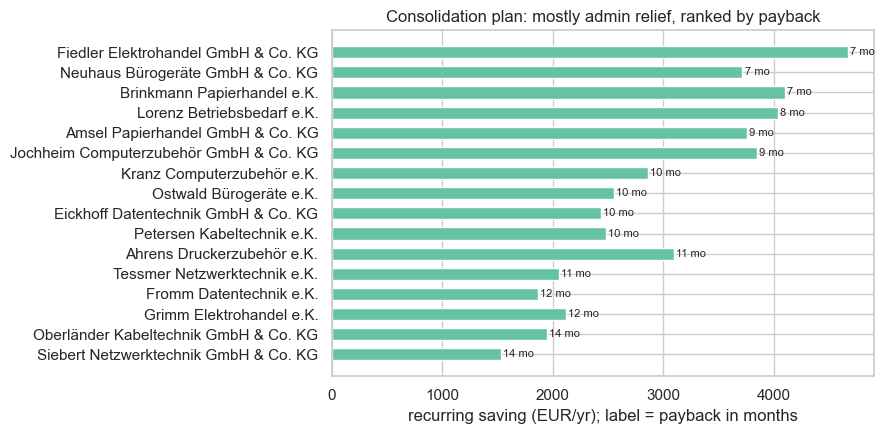

In [21]:
# ---- the consolidation plan the head of procurement actually gets ----
plan = cand[(~cand.category.isin(protected)) & (cand.saving_yr > 0)] \
           .sort_values("payback_m")[["category", "target", "spend_yr", "saving_yr", "one_off", "payback_m"]]
plan = plan[plan.payback_m <= 18]
print(f"consolidate {len(plan)} tail suppliers (payback <= 18 months, protected categories excluded):")
print(plan.round(0).astype({"spend_yr": int, "saving_yr": int, "one_off": int, "payback_m": int}).to_string())
print(f"\nTOTAL: EUR {plan.saving_yr.sum():,.0f}/yr recurring, EUR {plan.one_off.sum():,.0f} one-off, "
      f"portfolio payback {plan.one_off.sum() / plan.saving_yr.sum() * 12:.0f} months")
print(f"deliberately NOT consolidated: {', '.join(protected)} — the risk math above")

# FIG 5 — the plan at a glance
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plan.index[::-1], plan.saving_yr[::-1], color="#66c2a5", height=0.6)
for y_, (s_, pb) in enumerate(zip(plan.saving_yr[::-1], plan.payback_m[::-1])):
    ax.text(s_ + 20, y_, f"{pb:.0f} mo", va="center", fontsize=8)
ax.set_xlabel("recurring saving (EUR/yr); label = payback in months")
ax.set_title("Consolidation plan: mostly admin relief, ranked by payback")
plt.tight_layout()

The deliverable: **fold 16 tail suppliers into category leaders — €47,101/yr recurring for €37,474 one-off, portfolio payback 10 months** — with laptops & PCs and monitors deliberately left dual-sourced and the risk math attached to the exception. Every row shows its own payback, so the plan survives a CFO reading it backwards.

And a proportion check, because honest analytics states its own size: €47 k is **0.4 % of spend**. Tail consolidation is hygiene — worth doing, cheerfully self-funding, and *not* where the money was. The money was §1's €117 k of maverick spend, §2's €175 k of like-for-like price variance, and §4's TCO reversal on half a million of toner. The plan's job is to also *stop the tail growing back*: every consolidated supplier is one fewer place for next year's maverick lines to hide.

## 6. What real procurement systems add (honest section)

Everything above is the load-bearing 80 %. What production procurement analytics adds — and what this notebook quietly assumed away:

- **Spend classification is the actual hard problem.** Our lines arrived with clean `category` and `item` columns. Real spend arrives as free-text — *"HP 305XL cy. TINTE"*, *"Tintenpatrone HP 305 XL cyan"* and *"HP305XL C"* are one item — plus invoices with no PO at all. Mapping millions of such lines onto a taxonomy (UNSPSC, eCl@ss) is where procurement-analytics projects actually spend their first year; modern teams attack it with exactly the text-classification and LLM tooling Module 8 builds (NB 30 onward).
- **Compliance beats analysis.** Our maverick number is a *diagnosis*; the cure is process — catalogs, punch-out, three-way match (PO ↔ goods receipt ↔ invoice), approval workflows. A P2P system that makes the contract the path of least resistance beats any dashboard that scolds people afterwards.
- **Supplier risk is a data feed, not a column.** Real programs buy financial-health scores (a supplier PD — A3's machinery pointed the other way), geographic and logistics exposure, cyber ratings, and ESG/LkSG compliance data (the German supply-chain act made this a legal requirement, not a virtue). Our `net 14` hint was a toy version of a real signal.
- **Negotiation is a game, not a regression.** RFQs, reverse auctions, BAFO rounds, bundling strategies — should-cost tells you *what* to demand; auction design and game theory decide *how*. Beware the winner's curse: the supplier who most underestimated their costs wins your business, then fails your OTIF.
- **The top five suppliers are a relationship, not a row.** For strategic suppliers the category manager knows things no scorecard holds — the roadmap, the key account manager's clout, who answers the phone in an allocation crisis. The scorecard's real job is the *other* 55 suppliers, where nobody's memory reaches.
- **What we did not solve:** demand was taken as given (NB 26 owns that side); the safety-stock formula assumed normal, independent lead times (Wexler's mixture already bends it); admin costs were point estimates; and a real consolidation would re-tender prices rather than assume the target's current level.

## 🧠 The story in one screen

| # | The move | The number that carries it |
|---|---|---|
| 1 | Spend cube + Pareto over 14,000 PO lines | 17 A-suppliers = 69.5 % of €10.88 M; 25 C-suppliers share 10.5 % |
| 1 | Maverick spend, priced against a like-for-like benchmark | **€116,936/yr** (planted truth €106,931 — the estimate is honest) |
| 2 | Naive vs honest savings | €968,594 → **€175,203**; the €793 k gap is lot size, rush and steel |
| 2 | Should-cost regression: residuals, not price averages | Pfeiffer **+3.67 %** above should-cost (R² 0.983, rush +5.4 %, steel 0.35) |
| 3 | Same mean lead time, different σ (7.1 ± 0.8 vs 6.8 ± 3.6) | +90 units safety stock, **€1,490/yr**, or 95 % → **72 %** service |
| 3 | Scorecard weights argued in euros, not by committee | price 41 %, **quality 34 %**; 25 of 52 suppliers move 5+ ranks |
| 4 | Terms are money: 2/10 net 30 | skipping = borrowing at **45 % APR** |
| 4 | Total cost of ownership per €100 of catalogue | cheapest invoice (104.88) **loses** at 113.80; Weidner wins at 109.50 |
| 5 | Consolidation with two brakes (switching cost, risk cap) | 16 suppliers, **€47,101/yr**, payback 10 months; laptops & monitors stay dual for €114 and €1,589/yr above fair |

Three lessons to keep: **averages hide the variance that costs money** (the mean-lead-time league crowned the worst supplier); **a saving only exists like-for-like and in total cost** (€968 k of "savings" shrank to €175 k, and the cheapest price lost the TCO race); and **expected value is not a risk policy** (single-sourcing "won" on expectation everywhere — the €100 k cap and its stated insurance premium are what a decision looks like).

## 🧪 Practice exercises

Try each one **before** opening the solution. Starters run as-is.

### Exercise 1 — ⭐ Slice the cube

Two questions the head of procurement will ask in the first week, answerable straight from `po`: **(a)** the top-3 monitor suppliers by annual spend, with the top-3's combined share of the category; **(b)** the department with the worst maverick rate.

In [22]:
# Starter
# (a) po[po.category == "monitors"].groupby("supplier").value.sum() ... / 2 for EUR/yr
# (b) po.groupby("buyer").maverick.mean()


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
mon = po[po.category == "monitors"]
top3 = mon.groupby("supplier").value.sum().sort_values(ascending=False) / 2
print("monitors, EUR/yr and share:")
print((top3.head(3) / 1e3).round(0).astype(int).to_string())
print(f"top-3 share of the category: {top3.head(3).sum() / top3.sum():.0%}")
worst = po.groupby("buyer").maverick.mean().sort_values(ascending=False)
print(f"\nworst maverick buyer: {worst.index[0]} at {worst.iloc[0]:.0%} of lines off-contract")
```

Monitors are effectively a two-horse category — the top 3 hold **93 %** — which is exactly why §5 refused to single-source it. And `regional offices` runs a **32 %** maverick rate: the fix is a catalog rollout, not a memo.
</details>

### Exercise 2 — ⭐⭐ A league table with a floor

Rebuild the OTIF league **without** §3's 30-line floor and print the top three. Who "wins", on how many lines? Then reapply the floor and name the real champion. Why is the unfiltered table not merely noisy but *systematically* biased toward small suppliers at the top?

In [23]:
# Starter
# league_all = (po.on_time & po.in_full).groupby(po.supplier).mean().sort_values(ascending=False)
# n_lines = po.groupby("supplier").size()


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
league_all = ((po.on_time & po.in_full).groupby(po.supplier).mean().sort_values(ascending=False))
n_lines = po.groupby("supplier").size()
print("unfiltered OTIF top 3:")
for s in league_all.index[:3]:
    print(f"  {s:34s} {league_all[s]:6.1%}  on {n_lines[s]:>4} lines")
league = league_all[n_lines >= 30]
print(f"\nwith a >=30-line floor the champion is {league.index[0]} ({league.iloc[0]:.1%}, "
      f"{n_lines[league.index[0]]} lines)")
print("a perfect score on a handful of lines is luck wearing a medal — Stretch A puts a CI on it")
```

Three tiny suppliers post a perfect 100 % — the biggest of them on 24 lines — while the true champion, Druckwerk (98.2 % on **1,009** lines), sits fourth. The bias is structural: extreme scores *require* small samples (a 1,000-line supplier essentially cannot stay at 100 %), so the top of an unfloored league is reserved for the suppliers you know least about. Same disease as small-school league tables; Stretch A adds the error bars.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the savings that weren't

A colleague benchmarks this year's cable prices against last year's and drafts a memo. Their code runs without error — that is the problem:

```python
cab = po[po.category == "cables & adapters"]
avg = cab.groupby("year").unit_price.mean()
print(f"average cable price change: {avg[2025] / avg[2024] - 1:+.1%}")
# -> 'prices are UP — the 2025 renegotiation failed'
```

Procurement *renegotiated cable contracts down* for 2025 — and §1's generator really did plant a **−1.5 %** contract-price cut. Run the starter, find the flaw, and produce the number the memo should contain. (Hint: what else changed in 2025? Check the lot sizes. NB 10's Simpson's-paradox warning is watching.)

In [24]:
# their analysis — it runs fine, that's the problem
cab = po[po.category == "cables & adapters"]
avg = cab.groupby("year").unit_price.mean()
print(f"average cable price 2024: EUR {avg[2024]:.3f}  ->  2025: EUR {avg[2025]:.3f}  "
      f"({avg[2025] / avg[2024] - 1:+.1%})")
print("memo draft: 'cable prices rose — the 2025 renegotiation failed'")

average cable price 2024: EUR 8.204  ->  2025: EUR 8.308  (+1.3%)
memo draft: 'cable prices rose — the 2025 renegotiation failed'


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
cab = po[po.category == "cables & adapters"]
print(f"mean lot size: 2024 {cab[cab.year == 2024].qty.mean():.0f} -> 2025 {cab[cab.year == 2025].qty.mean():.0f}"
      "  <- the mix moved to small lots")
cell = cab.groupby(["item", "lot_band", "year"], observed=True).unit_price.mean().unstack("year")
wq = cab[cab.year == 2025].groupby(["item", "lot_band"], observed=True).qty.sum()
lfl = ((cell[2025] / cell[2024] - 1) * wq).sum() / wq[cell[2024].notna() & cell[2025].notna()].sum()
print(f"like-for-like price change (same item, same lot band, 2025-weighted): {lfl:+.1%}")
print("the renegotiation DID deliver — the average moved the other way because the basket changed")
```

A Simpson's-paradox costume drama. In 2025 the webshop moved to just-in-time cable ordering — mean lot size fell from **56 to 28** — and small lots legitimately pay more per unit (§2's price breaks). The *basket* got more expensive while every *price* got cheaper: like-for-like (same item, same lot band, weighted by this year's volumes) prices fell **−1.0 %**, in line with the planted −1.5 % cut. Never compare average prices across periods when the mix moved — compare within cells and reweight. The same bug, in the other direction, is how bad negotiations get celebrated.
</details>

### Exercise 4 — ⭐⭐ The terms menu

A key supplier offers three payment-term structures on €400,000 of annual spend: **2/10 net 30**, **1/10 net 60**, and plain **net 90**. Value each against a net-30 baseline (discounts assumed taken; days past 30 are financing at WACC), first at the webshop's 8 % cost of capital, then at 15 % (a cash-strapped year). Does the best choice change — and why does that make "best terms" a treasury question, not a procurement constant?

In [25]:
# Starter
# value = spend * discount + spend * (1 - discount) * wacc * (pay_day - 30) / 365   (if discounted)
# value = spend * wacc * (full_day - 30) / 365                                      (if plain terms)


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
offers = {"2/10 net 30": (10, 0.02, 30), "1/10 net 60": (10, 0.01, 60), "net 90": (90, 0.0, 90)}
spend_offer = 400_000
for wacc in (0.08, 0.15):
    print(f"WACC {wacc:.0%}:")
    for name, (pay_day, disc, full_day) in offers.items():
        val = spend_offer * disc + spend_offer * (1 - disc) * wacc * (pay_day - 30) / 365 \
              if disc else spend_offer * wacc * (full_day - 30) / 365
        print(f"  {name:12s} -> EUR {val:>8,.0f}/yr vs net 30")
    print()
```

At 8 % the discount wins (**€6,282/yr** vs €5,260 for net 90); at 15 % the ranking flips and the long terms win (**€9,863** vs €4,778) — expensive capital makes *keeping the cash* worth more than the 2 %. Terms are an interest-rate instrument: the right menu choice moved by thousands of euros without a single price changing, which is why A6 hands this decision to treasury.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Error bars for the league table

Exercise 2 showed *that* small-`n` suppliers game the league; now quantify it. For every supplier with fewer than 40 lines, bootstrap its OTIF (resample its lines 1,000×, take the 2.5/97.5 percentiles) and plot the league with error bars. One trap awaits: the bootstrap CI of a supplier with a *perfect* record has zero width (resampling successes only ever yields successes) — handle those with a **Wilson lower bound** instead, and report what a 100 %-on-15-lines record can actually rule out. (NB 10's CI machinery, meeting supplier management.)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
rng_b = np.random.default_rng(11)
n_lines = po.groupby("supplier").size()
small = n_lines[(n_lines < 40)].index
rows_ci = []
for s in small:
    ok = (po.loc[po.supplier == s, "on_time"] & po.loc[po.supplier == s, "in_full"]).to_numpy()
    boots = [rng_b.choice(ok, ok.size, replace=True).mean() for _ in range(1000)]
    rows_ci.append((s, ok.size, ok.mean(), np.percentile(boots, 2.5), np.percentile(boots, 97.5)))
ci = pd.DataFrame(rows_ci, columns=["supplier", "n", "otif", "lo", "hi"]).sort_values("otif", ascending=False)
print(ci.round(3).to_string(index=False))
z_ = 1.96   # a bootstrap of 15 successes has zero width — Wilson handles the extremes honestly
for s in ci[ci.otif == 1].supplier:
    n_, p_ = n_lines[s], 1.0
    lo = (p_ + z_**2 / (2 * n_) - z_ * math.sqrt((p_ * (1 - p_) + z_**2 / (4 * n_)) / n_)) / (1 + z_**2 / n_)
    print(f"{s}: OTIF 100% on {n_} lines -> Wilson 95% lower bound {lo:.0%}")
plt.figure(figsize=(8, 3.8))
plt.errorbar(ci.otif * 100, range(len(ci)),
             xerr=[(ci.otif - ci.lo) * 100, (ci.hi - ci.otif) * 100], fmt="o", color="#66c2a5")
plt.yticks(range(len(ci)), ci.supplier, fontsize=8)
plt.xlabel("OTIF % with bootstrap 95% CI")
plt.title("Small-n league tables: the error bars ARE the message")
plt.tight_layout()
```

The picture says it all: every sub-40-line CI spans ten-plus OTIF points, and the three 'perfect' suppliers have degenerate bootstrap intervals — the Wilson bound shows 100 % on 15 lines is consistent with a true OTIF as low as **80 %**, i.e. with being *worse than Wexler's league position*. Publish league tables with intervals, or with a volume floor; ideally both.
</details>

### Stretch exercise B — ⭐⭐ A Kraljic-style 2×2

The classic portfolio view: plot each category by **spend** (y) and **supply risk** (x — use the Herfindahl concentration of its supplier shares as a proxy) and split at the medians into the four textbook quadrants: *leverage* (high spend, low risk — negotiate hard), *strategic* (high/high — partner and dual-source), *routine* (low/low — automate), *bottleneck* (low spend, high risk — hold stock, qualify alternates). Where do laptops, toner and cables land — and does the map agree with §5's protected list?

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
herf = (po.groupby(["category", "supplier"]).value.sum()
        .groupby("category").apply(lambda v: ((v / v.sum())**2).sum()))
kr = pd.DataFrame({"spend": cat_spend / 1e3, "risk": herf})
plt.figure(figsize=(8, 4.5))
plt.scatter(kr.risk, kr.spend, s=40, color="#66c2a5")
for c, r in kr.iterrows():
    plt.annotate(c, (r.risk, r.spend), fontsize=8, xytext=(4, 3), textcoords="offset points")
plt.axvline(kr.risk.median(), color="#b3b3b3", ls="--", lw=1)
plt.axhline(kr.spend.median(), color="#b3b3b3", ls="--", lw=1)
plt.xlabel("supply concentration (Herfindahl of supplier shares)")
plt.ylabel("spend (kEUR/yr)")
plt.title("A Kraljic-style 2x2: leverage (top-left), strategic (top-right), routine, bottleneck")
plt.tight_layout()
print(kr.round(3).sort_values("spend", ascending=False).to_string())
```

Laptops (€2.3 M, Herfindahl 0.45) and monitors sit deep in *strategic* — precisely the two categories §5 kept dual-sourced, now for a reason you can draw. Cables and facility supplies land in *routine* (fragmented, small), where §5's consolidation candidates live. The 2×2 adds no new math; it makes §5's verdicts communicable to people who will never read a scenario table.
</details>

### Stretch exercise C — ⭐⭐⭐ The category price index vs the steel wave

Build a monthly **Laspeyres price index** for office furniture (base basket = the first quarter's item quantities; index each month's mean item prices against the base) and plot it against the published `STEEL` index. Did the buyers beat the input-cost wave, ride it, or overpay it — and how does your answer connect to the 0.35 elasticity the should-cost regression found in §2?

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
fur2 = po[po.category == "office furniture"].copy()
fur2["m"] = (fur2.year - 2024) * 12 + fur2.date.dt.month - 1
base_q = fur2[fur2.m < 3].groupby("item").qty.sum()          # base-period basket
base_p = fur2[fur2.m < 3].groupby("item").unit_price.mean()
idx = []
for m in sorted(fur2.m.unique()):
    pm = fur2[fur2.m == m].groupby("item").unit_price.mean()
    common = pm.index.intersection(base_q.index)
    idx.append(100 * (pm[common] * base_q[common]).sum() / (base_p[common] * base_q[common]).sum())
plt.figure(figsize=(8.5, 4))
plt.plot(sorted(fur2.m.unique()), idx, color="#66c2a5", lw=2, label="paid price index (Laspeyres)")
plt.plot(range(24), STEEL / STEEL[:3].mean() * 100, color="#fc8d62", lw=2, ls="--", label="steel input index")
plt.xlabel("month (0 = Jan 2024)")
plt.ylabel("index (first quarter = 100)")
plt.title("Furniture: what we paid vs what steel did")
plt.legend()
plt.tight_layout()
print(f"steel peaked {STEEL.max() / STEEL[:3].mean() - 1:+.0%} vs the base quarter; "
      f"paid prices peaked {max(idx) / 100 - 1:+.0%} — the ~0.38 pass-through the should-cost model found")
```

Steel peaked **+14 %** over the base quarter; paid furniture prices peaked ~**+6 %** — a pass-through of roughly 0.4, matching both the planted contract (38 % steel content) and §2's regression (0.35). That is the *defensible* answer to 'furniture got expensive, is procurement asleep?': prices moved exactly as the contract formula says they must. An index that ignored the mix (Exercise 3's bug) could not make this defense.
</details>

### Stretch exercise D — ⭐⭐⭐ Pricing the second source

Generalize §5's insurance math for laptops & PCs: sweep the failure probability from 1 % to 12 % and plot the **break-even dual-source premium** for requalification times of 2, 4 and 8 weeks, against the quoted +1.5 % premium line. For which (p, weeks) region is the quoted premium a bargain? Then say — in one sentence a CFO would accept — why the webshop might rationally stay dual-sourced even in the region where the premium is 'overpaying'.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
cat_ = "laptops & PCs"
spend_cat = cat_spend[cat_]
weekly_margin = spend_cat / 0.70 / 52 * 0.30
ps = np.linspace(0.01, 0.12, 45)
plt.figure(figsize=(8.5, 4))
for weeks, color in [(2, "#8da0cb"), (4, "#66c2a5"), (8, "#fc8d62")]:
    disruption = weeks * weekly_margin + 0.15 * weeks * spend_cat / 52
    be = ps * disruption / (0.30 * spend_cat) * 100
    plt.plot(ps * 100, be, lw=2, color=color, label=f"{weeks} weeks to requalify")
plt.axhline(1.5, color="k", ls="--", lw=1)
plt.text(1.2, 1.6, "quoted second-source premium: 1.5%")
plt.xlabel("P(single source fails within a year), %")
plt.ylabel("break-even premium, % of dual volume")
plt.title(f"{cat_}: when is paying extra for a second source worth it?")
plt.legend()
plt.tight_layout()
print("above the dashed line the insurance is cheap at the quoted premium; below it you are overpaying")
```

With an 8-week requalification, the quoted 1.5 % breaks even near p ≈ 5 % — everything to the right is cheap insurance. And below the line the one-sentence defense is A3 §5's: *the premium buys a cap on the worst quarter, not a better expected value* — a company that cannot absorb a −€205 k quarter rationally overpays relative to the actuarial price, and the analysis's job is to state by how much (§5: €114/yr).
</details>

## 🎁 Bonus mini-project — the category strategy one-pager

Write `category_onepager(cat)` — the single page a category manager takes into the Monday sourcing meeting, generated entirely from `po` and this notebook's tables. For `"toner & ink"` it must contain, with numbers:

1. **The money:** annual spend, share of total, top suppliers with shares, maverick rate in the category and its € cost.
2. **The league:** the €-weighted scorecard for the category's suppliers (volume floor applied), with each supplier's OTIF, σ_LT, defect rate and terms — and one sentence on where the equal-weights version would have misled.
3. **The all-in bill:** the TCO-per-€100 table, naming the invoice-price winner and the TCO winner if they differ (here: they do).
4. **The sourcing stance:** single vs dual, argued with §5's arithmetic — expected disruption, worst case against the €100 k risk cap, and the premium worth paying if dual.
5. **Actions with owners and paybacks:** the tail suppliers to exit (payback in months), the terms to renegotiate (€/yr each, from §4's menu logic), and the one supplier conversation the should-cost residuals justify.

Format it as printed markdown (NB 23's memo pattern). The hard constraint, as always in this module: **every claim traceable to a number printed above it** — a one-pager the reader can audit is worth ten they must trust.

## ✅ Self-assessment checklist

- [ ] I can build a spend cube and read its Pareto/ABC structure — and say how many suppliers carry 80 % of spend and what the C-tail costs in admin.
- [ ] I can price maverick spend against a like-for-like benchmark built from the data, and explain why the estimate needn't match the planted truth exactly.
- [ ] I can separate legitimate price dispersion (lot size, rush, input costs) from negotiable premium — and explain, with the €968 k → €175 k collapse, why naive minimum-price savings claims are fiction.
- [ ] I can fit a should-cost regression and use *residuals* to name the genuinely overpriced supplier.
- [ ] I can compute OTIF, explain why ranking by average lead time promoted the worst supplier, and price a σ_LT gap in €/yr with NB 26's safety-stock formula.
- [ ] I can derive scorecard weights from euros at stake and show how equal weights reorder the league.
- [ ] I can assemble TCO per €100 of catalogue spend and defend a cheapest ≠ cheapest reversal to a skeptic.
- [ ] I can rank consolidation candidates by payback, apply a risk-appetite cap, and state the dual-source insurance premium in €/yr above the actuarial price.
- [ ] I know what this notebook did not solve: spend classification, contract compliance, supplier risk feeds — and where the scorecard defers to the category manager.

---

## 🚀 Where next

- **[Back to the module README](README.md)** for the map of NB 23–26 and the appendix track.
- **NB 26** is this notebook's other half: it forecasts the demand and sizes the stock that §3 priced suppliers against — reread its safety-stock section with σ_LT now in your toolkit.
- **A3 §5** for the original of §5's insurance framing (risk appetite as a priced policy overlay), and **A6** for the cash side of §4's payment terms — DSO, DPO and the financing gap.
- **Module 8 (`08_ai_engineering`)** — the honest section's confession becomes the curriculum: NB 30's text tooling is how real teams classify the messy spend data this notebook was allowed to skip.